## Import the library

In [1]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import optuna

In [2]:
pd.set_option('display.max_columns', 1000)

## Load the dataset


In [3]:
train_file_path = "../input/house-prices-advanced-regression-techniques/train.csv"
raw_dataset = pd.read_csv(train_file_path)
print("Full train dataset shape is {}".format(raw_dataset.shape))

Full train dataset shape is (1460, 81)


In [4]:
raw_dataset.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Optuna functions

In [5]:
def score_checker(model, x, y):
    return -cross_val_score(model, x, y, scoring="neg_root_mean_squared_error", cv=10).mean()

In [6]:
def elastic_trial(trial, x, y):
    alpha = trial.suggest_float("alpha", 0.01, 100, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.01, 0.99)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=1000000)
    return score_checker(model, x, y)

In [7]:
def ridge_trial(trial, x, y):
    alpha = trial.suggest_float("alpha", 0.01, 100, log=True)
    model = Ridge(alpha=alpha, max_iter=1000000)
    return score_checker(model, x, y)

In [8]:
def lasso_trial(trial, x, y):
    alpha = trial.suggest_float("alpha", 0.01, 100, log=True)
    model = Lasso(alpha=alpha, max_iter=1000000)
    return score_checker(model, x, y)

In [9]:
def dtree_trial(trial, x, y):
    max_depth = trial.suggest_int("max_depth", 1, 100)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 100)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 100)
    model = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)
    return score_checker(model, x, y)

In [10]:
def rforest_trial(trial, x, y):
    n_estimators = trial.suggest_int("n_estimators", 10, 1000)
    max_depth = trial.suggest_int("max_depth", 1, 100)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 100)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 100)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features=max_features)
    return score_checker(model, x, y)

## Preprocess Data

In [11]:
#All Preprocess as function
def Preprocess(dataset):
    dataset = dataset.drop('Id', axis=1)
    dataset['MSSubClass'] = dataset['MSSubClass'].astype(str)

    LotShape_Map = {
        "Reg": 4,
        "IR1": 3,
        "IR2": 2,
        "IR3": 1
    }
    dataset['LotShape'] = dataset['LotShape'].map(LotShape_Map).fillna(0).astype(int)
    dataset.head()
    
    Utilities_Map = {
        "AllPub": 4,
        "NoSewr": 3,
        "NoSeWa": 2,
        "ELO": 1
    }
    
    dataset['Utilities'] = dataset['Utilities'].map(Utilities_Map).fillna(0).astype(int)
    dataset.head()
    
    LandSlope_Map = {
        "Gtl": 3,
        "Mod": 2,
        "Sev": 1
    }
    
    dataset['LandSlope'] = dataset['LandSlope'].map(LandSlope_Map).fillna(0).astype(int)
    dataset.head()
    
    ExterQual_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }
    
    dataset['ExterQual'] = dataset['ExterQual'].map(ExterQual_Map).fillna(0).astype(int)
    dataset.head()
    
    ExterCond_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }
    
    dataset['ExterCond'] = dataset['ExterCond'].map(ExterCond_Map).fillna(0).astype(int)
    dataset.head()
    
    BsmtQual_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1,
    }
    dataset['BsmtQual'] = dataset['BsmtQual'].map(BsmtQual_Map).fillna(0).astype(int)
    dataset.head()
    
    BsmtCond_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1,
    }
    dataset['BsmtCond'] = dataset['BsmtCond'].map(BsmtCond_Map).fillna(0).astype(int)
    dataset.head()
    
    BsmtExposure_Map = {
        "Gd": 4,
        "Av": 3,
        "Mn": 2,
        "No": 1,
    }
    dataset['BsmtExposure'] = dataset['BsmtExposure'].map(BsmtExposure_Map).fillna(0).astype(int)
    dataset.head()
    
    BsmtFinType1_Map = {
        "GLQ": 6,
        "ALQ": 5,
        "BLQ": 4,
        "Rec": 3,
        "LwQ": 2,
        "Unf": 1
    }
    dataset['BsmtFinType1'] = dataset['BsmtFinType1'].map(BsmtFinType1_Map).fillna(0).astype(int)
    dataset.head()
    
    BsmtFinType2_Map = {
        "GLQ": 6,
        "ALQ": 5,
        "BLQ": 4,
        "Rec": 3,
        "LwQ": 2,
        "Unf": 1
    }
    dataset['BsmtFinType2'] = dataset['BsmtFinType2'].map(BsmtFinType2_Map).fillna(0).astype(int)
    dataset.head()
    
    HeatingQC_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }
    dataset['HeatingQC'] = dataset['HeatingQC'].map(HeatingQC_Map).fillna(0).astype(int)
    dataset.head()
    
    CentralAir_Map = {
        "N": 0,
        "Y": 1
    }
    dataset['CentralAir'] = dataset['CentralAir'].map(CentralAir_Map).fillna(0).astype(int)
    dataset.head()
    
    Electrical_Map = {
        "Mix": 0,
        "FuseP": 1,
        "FuseF": 2,
        "FuseA": 3,
        "SBrkr": 4
    }
    dataset['Electrical'] = dataset['Electrical'].map(Electrical_Map).fillna(0).astype(int)
    dataset.head()
    
    KitchenQual_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }
    dataset['KitchenQual'] = dataset['KitchenQual'].map(KitchenQual_Map).fillna(0).astype(int)
    dataset.head()
    
    Functional_Map = {
        "Typ": 8,
        "Min1": 7,
        "Min2": 6,
        "Mod": 5,
        "Maj1": 4,
        "Maj2": 3,
        "Sev": 2,
        "Sal": 1
    }
    dataset['Functional'] = dataset['Functional'].map(Functional_Map).fillna(0).astype(int)
    dataset.head()
    
    FireplaceQu_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }
    dataset['FireplaceQu'] = dataset['FireplaceQu'].map(FireplaceQu_Map).fillna(0).astype(int)
    dataset.head()
    
    GarageFinish_Map = {
        "Fin": 3,
        "RFn": 2,
        "Unf": 1
    }
    dataset['GarageFinish'] = dataset['GarageFinish'].map(GarageFinish_Map).fillna(0).astype(int)
    dataset.head()
    
    GarageQual_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }
    dataset['GarageQual'] = dataset['GarageQual'].map(GarageQual_Map).fillna(0).astype(int)
    dataset.head()
    
    GarageCond_Map = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }
    dataset['GarageCond'] = dataset['GarageCond'].map(GarageCond_Map).fillna(0).astype(int)
    dataset.head()
    
    PavedDrive_Map = {
        "Y": 3,
        "P": 2,
        "N": 1
    }
    dataset['PavedDrive'] = dataset['PavedDrive'].map(PavedDrive_Map).fillna(0).astype(int)
    dataset.head()
    
    PoolQC_Map = {
        "Ex": 4,
        "Gd": 3,
        "TA": 2,
        "Fa": 1,
    }
    dataset['PoolQC'] = dataset['PoolQC'].map(PoolQC_Map).fillna(0).astype(int)
    dataset.head()

    dataset = pd.get_dummies(dataset)
    dataset.head()

    dataset["HouseAge"] = dataset["YrSold"] - dataset["YearRemodAdd"]

    dataset = dataset.where(dataset.notna(), 0)
    dataset = dataset.astype("float64")

    log_list = ["LotArea", "TotalBsmtSF", "BsmtFinSF1", "BsmtUnfSF", "BsmtFinSF2", "GrLivArea", "SalePrice"]
    for i in log_list:
        try:
            dataset[i] = np.log1p(dataset[i])
        except KeyError:
            continue

    return dataset

In [12]:
dataset = raw_dataset

In [13]:
dataset.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Remove Outlier


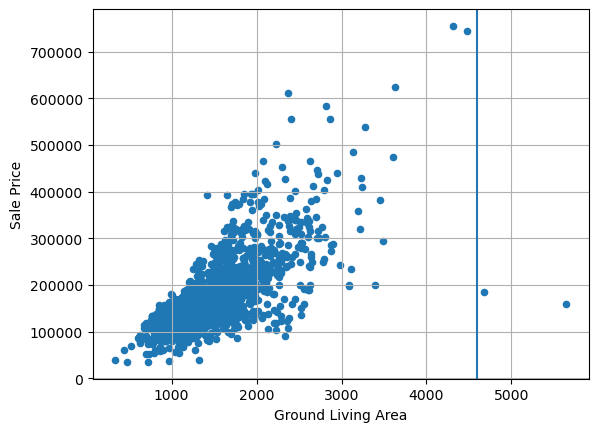

In [14]:
plt.scatter(dataset["GrLivArea"], dataset["SalePrice"], s=20)
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")
plt.grid()
plt.axvline(x=4600)
plt.show()

In [15]:
dataset = dataset[dataset["GrLivArea"]<4600]

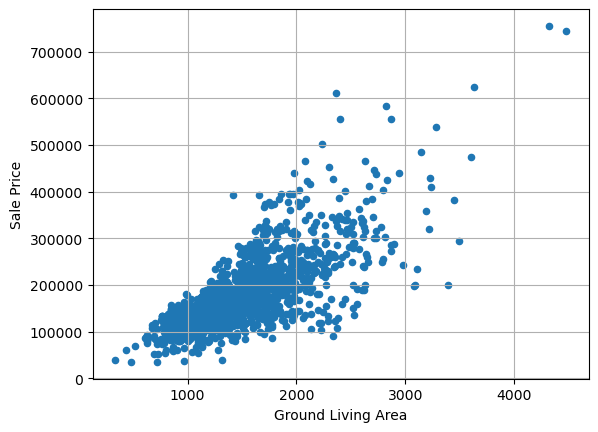

In [16]:
plt.scatter(dataset["GrLivArea"], dataset["SalePrice"], s=20)
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")
plt.grid()
plt.show()

In [17]:
plt.close()

In [18]:
dataset.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [19]:
dataset = Preprocess(dataset)

In [20]:
dataset.head()

,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SalePrice,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge
0,65.0,9.042040,4.0,4.0,3.0,7.0,5.0,2003.0,2003.0,196.0,4.0,3.0,4.0,3.0,1.0,6.0,6.561031,1.0,0.0,5.017280,6.753438,5.0,1.0,4.0,856.0,854.0,0.0,7.444833,1.0,0.0,2.0,1.0,3.0,1.0,4.0,8.0,8.0,0.0,0.0,2003.0,2.0,2.0,548.0,3.0,3.0,3.0,0.0,61.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2008.0,12.247699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0

In [21]:
dataset.isna().sum().sum()

0

In [22]:
target_label = "SalePrice"

X_dataset = dataset.drop(columns=target_label)
y_dataset = dataset[target_label]

In [23]:
X_dataset.head()

,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge
0,65.0,9.042040,4.0,4.0,3.0,7.0,5.0,2003.0,2003.0,196.0,4.0,3.0,4.0,3.0,1.0,6.0,6.561031,1.0,0.0,5.017280,6.753438,5.0,1.0,4.0,856.0,854.0,0.0,7.444833,1.0,0.0,2.0,1.0,3.0,1.0,4.0,8.0,8.0,0.0,0.0,2003.0,2.0,2.0,548.0,3.0,3.0,3.0,0.0,61.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2008.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0

In [24]:
y_dataset.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64

In [25]:
x_train, x_valid, y_train, y_valid = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=50)

In [26]:
print("{} examples in training, {} examples in testing.".format(
    len(x_train), len(x_valid)))

1166 examples in training, 292 examples in testing.


In [27]:
ridge_study = optuna.create_study(direction="minimize")
ridge_study.optimize(lambda trial: ridge_trial(trial, x_train, y_train), n_trials=100)
print(ridge_study.best_params)
print(ridge_study.best_value)

[I 2026-01-08 19:24:15,461] A new study created in memory with name: no-name-e4736135-d7ec-47d4-9a07-d7293ce8b78b
[I 2026-01-08 19:24:15,655] Trial 0 finished with value: 0.10890385213356601 and parameters: {'alpha': 71.2803346506097}. Best is trial 0 with value: 0.10890385213356601.
[I 2026-01-08 19:24:15,837] Trial 1 finished with value: 0.11368132389488894 and parameters: {'alpha': 0.01560579163985271}. Best is trial 0 with value: 0.10890385213356601.
[I 2026-01-08 19:24:16,023] Trial 2 finished with value: 0.10554554401189657 and parameters: {'alpha': 3.3733618809802364}. Best is trial 2 with value: 0.10554554401189657.
[I 2026-01-08 19:24:16,206] Trial 3 finished with value: 0.10529973361814052 and parameters: {'alpha': 5.194583598382}. Best is trial 3 with value: 0.10529973361814052.
[I 2026-01-08 19:24:16,383] Trial 4 finished with value: 0.1135830649287396 and parameters: {'alpha': 0.01903496676161976}. Best is trial 3 with value: 0.10529973361814052.
[I 2026-01-08 19:24:16,557

{'alpha': 7.0390491594623965}
0.10524866941854856


In [28]:
elastic_study = optuna.create_study(direction="minimize")
elastic_study.optimize(lambda trial: elastic_trial(trial, x_train, y_train), n_trials=100)
print(elastic_study.best_params)
print(elastic_study.best_value)

[I 2026-01-08 19:24:34,083] A new study created in memory with name: no-name-a09814a6-770c-4dad-98d8-6d3db4e293a5
[I 2026-01-08 19:24:34,466] Trial 0 finished with value: 0.14321167168871088 and parameters: {'alpha': 0.07520790768718437, 'l1_ratio': 0.4011171311972544}. Best is trial 0 with value: 0.14321167168871088.
[I 2026-01-08 19:24:34,631] Trial 1 finished with value: 0.24053153568045213 and parameters: {'alpha': 20.482951591087403, 'l1_ratio': 0.9271556280323311}. Best is trial 0 with value: 0.14321167168871088.
[I 2026-01-08 19:24:34,792] Trial 2 finished with value: 0.23513066911761932 and parameters: {'alpha': 52.90842317933432, 'l1_ratio': 0.3073440482704523}. Best is trial 0 with value: 0.14321167168871088.
[I 2026-01-08 19:24:34,951] Trial 3 finished with value: 0.24783198541350265 and parameters: {'alpha': 29.700793399420455, 'l1_ratio': 0.748065216437676}. Best is trial 0 with value: 0.14321167168871088.
[I 2026-01-08 19:24:35,371] Trial 4 finished with value: 0.15413883

{'alpha': 0.010256975437097842, 'l1_ratio': 0.015520046803167997}
0.10499581643755314


In [29]:
lasso_study = optuna.create_study(direction="minimize")
lasso_study.optimize(lambda trial: lasso_trial(trial, x_train, y_train), n_trials=100)
print(lasso_study.best_params)
print(lasso_study.best_value)

[I 2026-01-08 19:30:13,693] A new study created in memory with name: no-name-e26ead4a-cea9-429a-8327-46381ebf99e0
[I 2026-01-08 19:30:13,866] Trial 0 finished with value: 0.22214113373527605 and parameters: {'alpha': 7.144479898147179}. Best is trial 0 with value: 0.22214113373527605.
[I 2026-01-08 19:30:14,244] Trial 1 finished with value: 0.13722466021405919 and parameters: {'alpha': 0.02145975921068108}. Best is trial 1 with value: 0.13722466021405919.
[I 2026-01-08 19:30:14,419] Trial 2 finished with value: 0.1993965519202467 and parameters: {'alpha': 2.3414297892378477}. Best is trial 1 with value: 0.13722466021405919.
[I 2026-01-08 19:30:14,732] Trial 3 finished with value: 0.1725509067634457 and parameters: {'alpha': 0.647966141964561}. Best is trial 1 with value: 0.13722466021405919.
[I 2026-01-08 19:30:14,900] Trial 4 finished with value: 0.20133749362904102 and parameters: {'alpha': 2.468972934359673}. Best is trial 1 with value: 0.13722466021405919.
[I 2026-01-08 19:30:15,05

{'alpha': 0.010008828739548975}
0.12437886520819194


In [30]:
dtree_study = optuna.create_study(direction="minimize")
dtree_study.optimize(lambda trial: dtree_trial(trial, x_train, y_train), n_trials=100)
print(dtree_study.best_params)
print(dtree_study.best_value)

[I 2026-01-08 19:30:53,716] A new study created in memory with name: no-name-b5a75670-53ac-413e-9fe6-fb44efb90cc5
[I 2026-01-08 19:30:53,961] Trial 0 finished with value: 0.21309725357677872 and parameters: {'max_depth': 96, 'min_samples_split': 37, 'min_samples_leaf': 50}. Best is trial 0 with value: 0.21309725357677872.
[I 2026-01-08 19:30:54,151] Trial 1 finished with value: 0.23293352749877752 and parameters: {'max_depth': 14, 'min_samples_split': 63, 'min_samples_leaf': 83}. Best is trial 0 with value: 0.21309725357677872.
[I 2026-01-08 19:30:54,395] Trial 2 finished with value: 0.1973488429699884 and parameters: {'max_depth': 48, 'min_samples_split': 76, 'min_samples_leaf': 8}. Best is trial 2 with value: 0.1973488429699884.
[I 2026-01-08 19:30:54,599] Trial 3 finished with value: 0.2210401701814006 and parameters: {'max_depth': 87, 'min_samples_split': 52, 'min_samples_leaf': 62}. Best is trial 2 with value: 0.1973488429699884.
[I 2026-01-08 19:30:54,823] Trial 4 finished with v

{'max_depth': 57, 'min_samples_split': 8, 'min_samples_leaf': 9}
0.179365631273894


In [31]:
rforest_study = optuna.create_study(direction="minimize")
rforest_study.optimize(lambda trial: rforest_trial(trial, x_train, y_train), n_trials=100)
print(rforest_study.best_params)
print(rforest_study.best_value)

[I 2026-01-08 19:31:22,117] A new study created in memory with name: no-name-153244ea-f358-4ec6-bf22-2a76886d769c
[I 2026-01-08 19:31:29,515] Trial 0 finished with value: 0.20001437186202492 and parameters: {'n_estimators': 399, 'max_depth': 94, 'min_samples_split': 41, 'min_samples_leaf': 43, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.20001437186202492.
[I 2026-01-08 19:31:33,307] Trial 1 finished with value: 0.19786090854939742 and parameters: {'n_estimators': 203, 'max_depth': 88, 'min_samples_split': 83, 'min_samples_leaf': 39, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.19786090854939742.
[I 2026-01-08 19:31:47,546] Trial 2 finished with value: 0.18297298622274077 and parameters: {'n_estimators': 720, 'max_depth': 70, 'min_samples_split': 29, 'min_samples_leaf': 26, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.18297298622274077.
[I 2026-01-08 19:31:55,355] Trial 3 finished with value: 0.21447742920206606 and parameters: {'n_estimators': 484, 'max_d

{'n_estimators': 880, 'max_depth': 46, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
0.13525908907560086


In [32]:
final_LinearRegression = LinearRegression()
final_LinearRegression.fit(x_train, y_train)

LinearRegression()

In [33]:
final_Ridge = Ridge(alpha=ridge_study.best_params["alpha"])
final_Ridge.fit(x_train, y_train)

Ridge(alpha=7.0390491594623965)

In [34]:
final_Lasso = Lasso(alpha=lasso_study.best_params["alpha"])
final_Lasso.fit(x_train, y_train)

Lasso(alpha=0.010008828739548975)

In [35]:
final_ElasticNet = ElasticNet(alpha=elastic_study.best_params["alpha"], l1_ratio=elastic_study.best_params["l1_ratio"])
final_ElasticNet.fit(x_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.279e+00, tolerance: 1.831e-02
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive


ElasticNet(alpha=0.010256975437097842, l1_ratio=0.015520046803167997)

In [36]:
final_DecisionTreeRegressor = DecisionTreeRegressor(max_depth=dtree_study.best_params["max_depth"], min_samples_split=dtree_study.best_params["min_samples_split"], min_samples_leaf=dtree_study.best_params["min_samples_leaf"])
final_DecisionTreeRegressor.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=57, min_samples_leaf=9, min_samples_split=8)

In [37]:
final_RandomForestRegressor = RandomForestRegressor(n_estimators=rforest_study.best_params["n_estimators"], max_depth=rforest_study.best_params["max_depth"], min_samples_split=rforest_study.best_params["min_samples_split"], min_samples_leaf=rforest_study.best_params["min_samples_leaf"], max_features=rforest_study.best_params["max_features"])
final_RandomForestRegressor.fit(x_train, y_train)

RandomForestRegressor(max_depth=46, max_features='sqrt', n_estimators=880)

In [38]:
lr_predict = final_LinearRegression.predict(x_valid)
ridge_predict = final_Ridge.predict(x_valid)
lasso_predict = final_Lasso.predict(x_valid)
elastic_predict = final_ElasticNet.predict(x_valid)
dtree_predict = final_DecisionTreeRegressor.predict(x_valid)
rforest_predict = final_RandomForestRegressor.predict(x_valid)

final_predict = {
    "lr_predict": lr_predict,
    "ridge_predict": ridge_predict,
    "lasso_predict": lasso_predict,
    "elastic_predict": elastic_predict,
    "dtree_predict": dtree_predict,
    "rforest_predict": rforest_predict,
}
final_mse = []

for model, predict in final_predict.items():
    print(f'MSE for {model} is {mean_squared_error(y_valid, predict)}')
    final_mse.append([model, mean_squared_error(y_valid, predict)])
    

MSE for lr_predict is 0.0193439975908871
MSE for ridge_predict is 0.01708263259215996
MSE for lasso_predict is 0.02156037739124397
MSE for elastic_predict is 0.016931190983431335
MSE for dtree_predict is 0.03776683601806753
MSE for rforest_predict is 0.02255840522870662


In [39]:
best_model = min(final_mse, key=lambda x: x[1])
print(best_model)

['elastic_predict', 0.016931190983431335]


In [40]:
final_model = final_LinearRegression

if best_model[0] == "lr_predict":
    final_model = final_LinearRegression
if best_model[0] == "ridge_predict":
    final_model = final_Ridge
if best_model[0] == "lasso_predict":
    final_model = final_Lasso
if best_model[0] == "elastic_predict":
    final_model = final_ElasticNet
if best_model[0] == "dtree_predict":
    final_model = final_DecisionTreeRegressor
if best_model[0] == "rforest_predict":
    final_model = final_RandomForestRegressor

In [42]:
test_file_path = "../input/house-prices-advanced-regression-techniques/test.csv"

test_data = pd.read_csv(test_file_path)
ids = test_data['Id']

test_data = Preprocess(test_data)
test_data = test_data.reindex(columns=dataset.columns, fill_value = 0)
x_test = test_data.drop(columns="SalePrice")

preds = np.expm1(final_model.predict(x_test))
output = pd.DataFrame({'Id': ids,
                       'SalePrice': preds.squeeze()})

output.head()


,Id,SalePrice
0,1461,116531.037495
1,1462,147849.053303
2,1463,177629.369236
3,1464,193097.507341
4,1465,192227.773347


In [43]:
sample_submission_df = pd.read_csv('../input/house-prices-advanced-regression-techniques/sample_submission.csv')
sample_submission_df['SalePrice'] = np.expm1(final_model.predict(x_test))
sample_submission_df.to_csv('/kaggle/working/submission.csv', index=False)
sample_submission_df.head()

,Id,SalePrice
0,1461,116531.037495
1,1462,147849.053303
2,1463,177629.369236
3,1464,193097.507341
4,1465,192227.773347
